# 자속 가변 Transmon (SQUID)

이 노트북에서는 SQUID 루프를 기반으로 한 자속 가변 Transmon 큐비트를 다룹니다.

**다루는 내용:**
- 유효 조셉슨 에너지 $E_J(\Phi_{\text{ext}})$
- 자속에 따른 에너지 스펙트럼
- 대칭 vs 비대칭 SQUID
- 회로 기반 SQUID 검증

In [1]:
using ScQubitsMimic
using CairoMakie

_scqubitsmimic_example_dir = normpath(joinpath(dirname(pathof(ScQubitsMimic)), "..", "examples"))
if !isdefined(Main, :ScQubitsMimicExampleMakie)
    include(joinpath(_scqubitsmimic_example_dir, "makie_fontsetup.jl"))
end
ScQubitsMimicExampleMakie.setup_makie_font!()


"Apple SD Gothic Neo"

## 1. SQUID 기반 Transmon 해밀토니안

두 개의 조셉슨 접합($E_{J1}$, $E_{J2}$)이 루프를 형성하는 SQUID 구조에서, 외부 자속 $\Phi_{\text{ext}}$에 의해 유효 조셉슨 에너지가 조절됩니다:

$$E_J(\Phi_{\text{ext}}) = E_{J,\max} \left|\cos\left(\pi\frac{\Phi_{\text{ext}}}{\Phi_0}\right)\right| \sqrt{1 + d^2 \tan^2\left(\pi\frac{\Phi_{\text{ext}}}{\Phi_0}\right)}$$

여기서:
- $E_{J,\max} = E_{J1} + E_{J2}$: 최대 조셉슨 에너지
- $d = (E_{J2} - E_{J1})/(E_{J1} + E_{J2})$: 접합 비대칭도
- $\Phi_0 = h/(2e)$: 자속 양자

대칭 SQUID ($d=0$)에서는 절반 자속 양자($\Phi_{\text{ext}} = \Phi_0/2$)에서 $E_J = 0$이 됩니다.

In [2]:
tmon = TunableTransmon(EJmax=15.0, EC=0.6, d=0.1, flux=0.0, ncut=30, truncated_dim=6)

println("TunableTransmon 파라미터:")
println("  EJmax = $(tmon.EJmax) GHz")
println("  EC = $(tmon.EC) GHz")
println("  d (비대칭도) = $(tmon.d)")
println("  EJmax/EC = $(tmon.EJmax / tmon.EC)")

TunableTransmon 파라미터:
  EJmax = 15.0 GHz
  EC = 0.6 GHz
  d (비대칭도) = 0.1
  EJmax/EC = 25.0


## 2. 유효 조셉슨 에너지 vs 외부 자속

외부 자속을 $0$에서 $\Phi_0$까지 변화시키면서 유효 $E_J$의 변화를 관찰합니다.

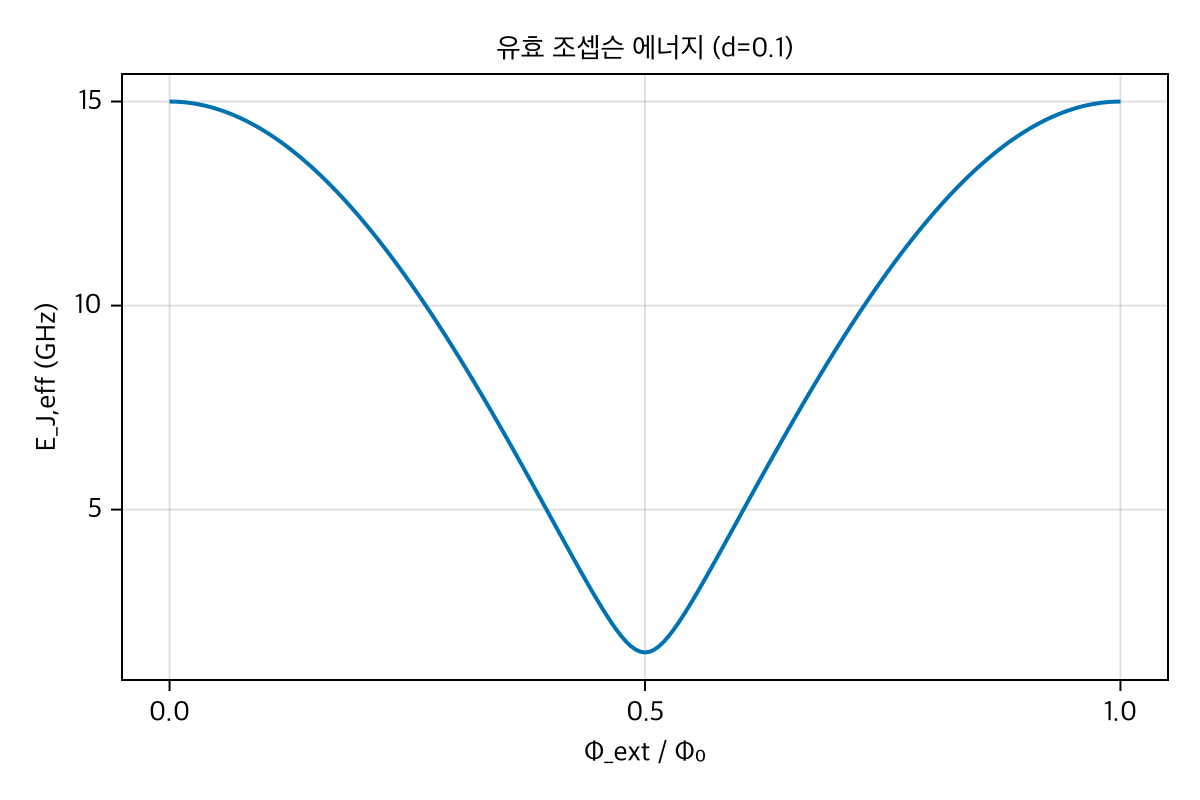

In [3]:
fluxes = range(0.0, 1.0, length=201)
ej_vals = Float64[]
for f in fluxes
    tmon.flux = f
    push!(ej_vals, ej_effective(tmon))
end
tmon.flux = 0.0

fig = Figure(size=(600, 400))
ax = Axis(fig[1, 1],
    xlabel="Φ_ext / Φ₀",
    ylabel="E_J,eff (GHz)",
    title="유효 조셉슨 에너지 (d=$(tmon.d))")
lines!(ax, collect(fluxes), ej_vals, linewidth=2)
fig

## 3. 에너지 스펙트럼 vs 외부 자속

자속 변화에 따른 에너지 준위의 변화를 스펙트럼으로 나타냅니다. $\Phi_{\text{ext}} = 0$에서 전이 주파수가 최대이며 (sweet spot), $\Phi_{\text{ext}} = \Phi_0/2$에서 최소입니다.

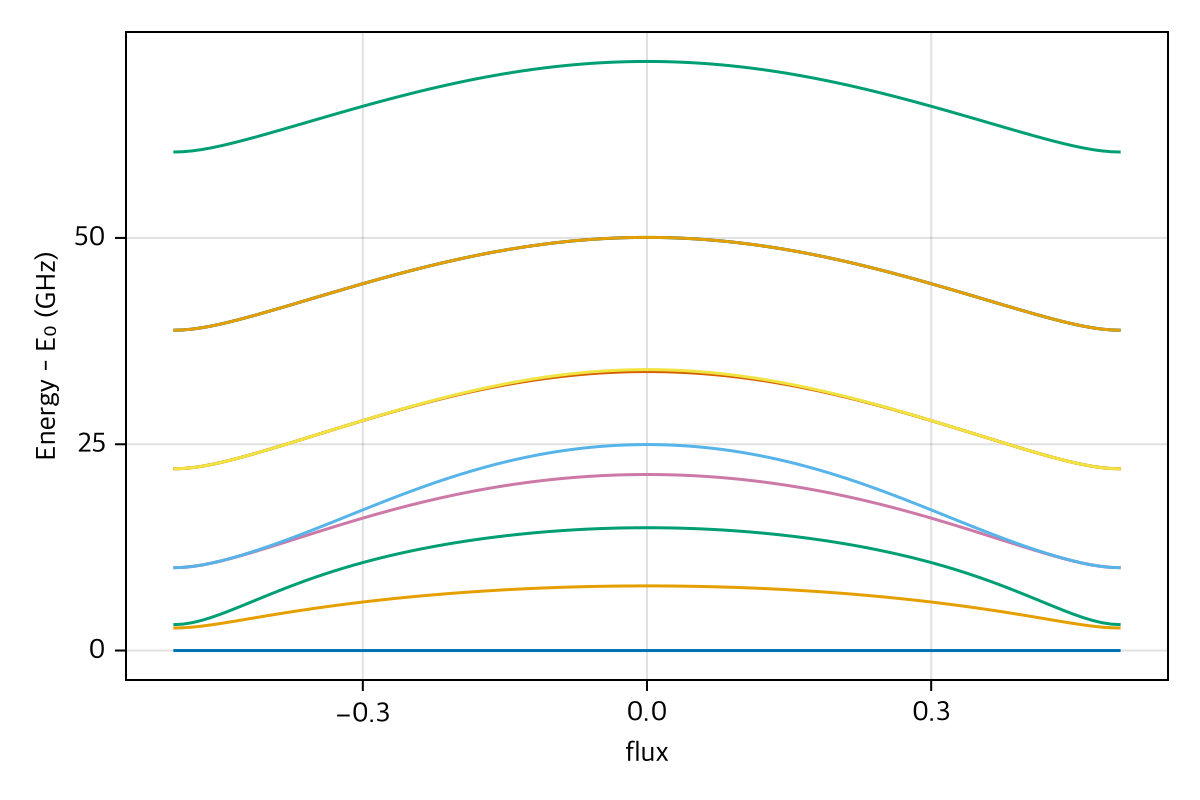

In [4]:
tmon.flux = 0.0
sweep = ParameterSweep(tmon, :flux, range(-0.5, 0.5, length=101); evals_count=10)
plot_evals_vs_paramvals(sweep; subtract_ground=true, evals_count=10)

In [5]:
# 주요 자속 지점에서의 전이 주파수와 비조화성
println("  Φ/Φ₀      ω₀₁ (GHz)    α (GHz)")
println("  " * "-"^35)
for flux in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
    tmon.flux = flux
    e = eigenvals(tmon; evals_count=3)
    w01 = e[2] - e[1]
    w12 = e[3] - e[2]
    α = w12 - w01
    println("  $(round(flux, digits=2))       $(round(w01, digits=4))      $(round(α, digits=4))")
end
tmon.flux = 0.0

  Φ/Φ₀      ω₀₁ (GHz)    α (GHz)
  -----------------------------------
  0.0       7.8336      -0.7831
  0.1       7.6243      -0.7987
  0.2       6.9858      -0.8659
  0.3       5.8794      -1.0962
  0.4       4.2388      -1.757
  0.5       2.7311      -2.3237


0.0

## 4. 대칭 vs 비대칭 SQUID

접합 비대칭도 $d$는 절반 자속 양자(frustration point, $\Phi_{\text{ext}} = \Phi_0/2$) 부근에서의 동작에 큰 영향을 줍니다:

- **대칭 SQUID** ($d = 0$): $E_J(\Phi_0/2) = 0$ → 주파수가 0에 수렴
- **비대칭 SQUID** ($d \neq 0$): $E_J(\Phi_0/2) = E_{J,\max} \cdot d$ → 잔여 주파수 존재

비대칭 SQUID는 frustration point 부근에서 자속 잡음에 대한 1차 감도가 사라지는 "sweet spot"을 제공합니다.

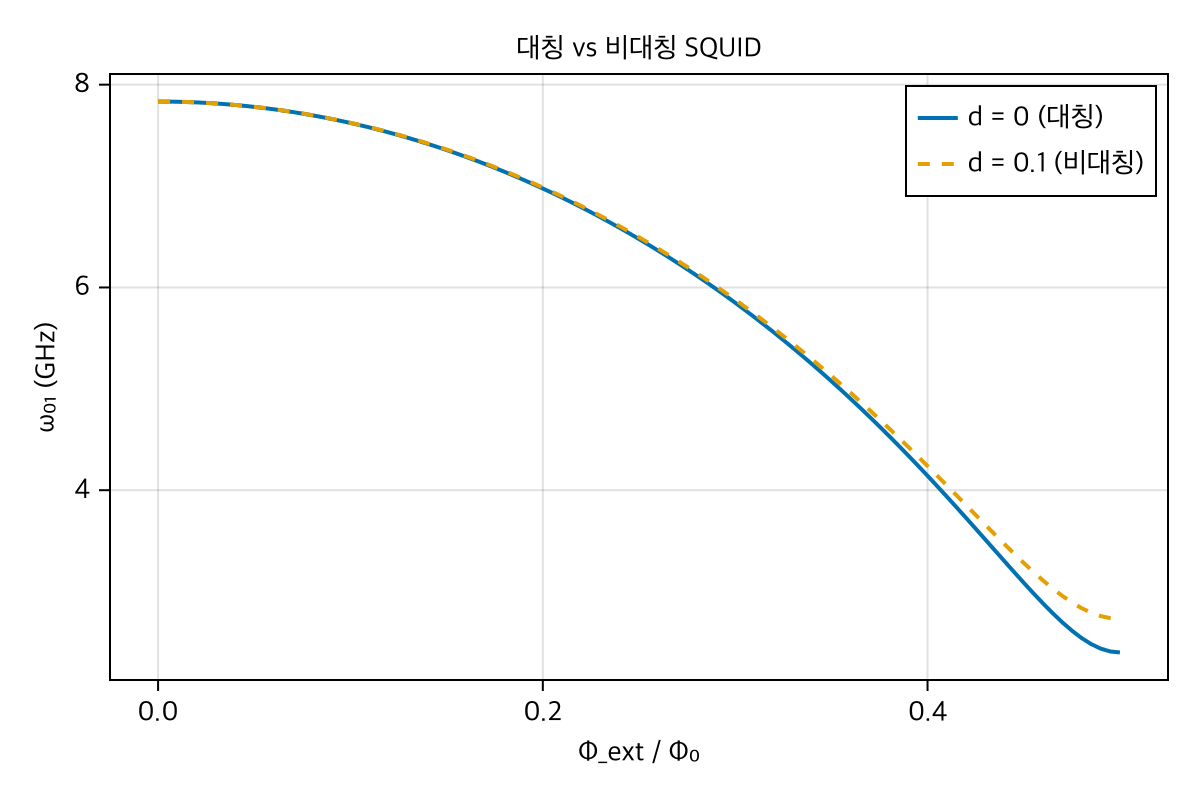

In [6]:
tmon_sym = TunableTransmon(EJmax=15.0, EC=0.6, d=0.0, flux=0.0, ncut=30, truncated_dim=4)
tmon_asym = TunableTransmon(EJmax=15.0, EC=0.6, d=0.1, flux=0.0, ncut=30, truncated_dim=4)

flux_range = range(0.0, 0.5, length=101)
w01_sym = Float64[]
w01_asym = Float64[]

for f in flux_range
    tmon_sym.flux = f
    tmon_asym.flux = f
    e_s = eigenvals(tmon_sym; evals_count=2)
    e_a = eigenvals(tmon_asym; evals_count=2)
    push!(w01_sym, e_s[2] - e_s[1])
    push!(w01_asym, e_a[2] - e_a[1])
end

fig = Figure(size=(600, 400))
ax = Axis(fig[1, 1],
    xlabel="Φ_ext / Φ₀",
    ylabel="ω₀₁ (GHz)",
    title="대칭 vs 비대칭 SQUID")
lines!(ax, collect(flux_range), w01_sym, label="d = 0 (대칭)", linewidth=2)
lines!(ax, collect(flux_range), w01_asym, label="d = 0.1 (비대칭)", linewidth=2, linestyle=:dash)
axislegend(ax)
fig

In [7]:
# Frustration point에서의 비교
tmon_sym.flux = 0.5
tmon_asym.flux = 0.5

println("Φ/Φ₀ = 0.5 (frustration point):")
println("  대칭:   EJ_eff = $(round(ej_effective(tmon_sym), digits=6)) GHz")
println("  비대칭: EJ_eff = $(round(ej_effective(tmon_asym), digits=6)) GHz")

e_sym = eigenvals(tmon_sym; evals_count=2)
e_asym = eigenvals(tmon_asym; evals_count=2)
println("  대칭:   ω₀₁ = $(round(e_sym[2] - e_sym[1], digits=4)) GHz")
println("  비대칭: ω₀₁ = $(round(e_asym[2] - e_asym[1], digits=4)) GHz")

Φ/Φ₀ = 0.5 (frustration point):
  대칭:   EJ_eff = 0.0 GHz
  비대칭: EJ_eff = 1.5 GHz
  대칭:   ω₀₁ = 2.4 GHz
  비대칭: ω₀₁ = 2.7311 GHz


## 5. 회로 기반 SQUID 검증

`Circuit`으로 두 개의 JJ 브랜치를 병렬로 연결하여 SQUID를 구성하고, `TunableTransmon`과 비교합니다.

대칭 SQUID의 회로 기술:
- JJ1: $E_{J1} = E_{J,\max}/2 = 7.5$ GHz
- JJ2: $E_{J2} = E_{J,\max}/2 = 7.5$ GHz
- $E_{C,\text{branch}} = 0.3$ GHz → $E_{C,\text{total}} = 0.6$ GHz

In [8]:
desc = """
branches:
  - [JJ, 0, 1, EJ=7.5, EC=0.3]
  - [JJ, 0, 1, EJ=7.5, EC=0.3]
"""
circ = Circuit(desc; ncut=30)
println("외부 자속 변수 수: $(length(circ.external_flux_values))")

println("\n자속별 비교 (대칭 SQUID):")
println("  Φ/Φ₀     TunableTransmon ω₀₁    Circuit ω₀₁")
println("  " * "-"^50)
for flux in [0.0, 0.125, 0.25, 0.375]
    tt = TunableTransmon(EJmax=15.0, EC=0.6, d=0.0, flux=flux, ncut=30, truncated_dim=3)
    e_tt = eigenvals(tt; evals_count=3)

    set_external_flux!(circ, 1, 2π * flux)
    e_circ = eigenvals(circ; evals_count=3)

    w01_tt = e_tt[2] - e_tt[1]
    w01_circ = e_circ[2] - e_circ[1]
    println("  $(round(flux, digits=3))     $(round(w01_tt, digits=4))              $(round(w01_circ, digits=4))")
end

외부 자속 변수 수: 1

자속별 비교 (대칭 SQUID):
  Φ/Φ₀     TunableTransmon ω₀₁    Circuit ω₀₁
  --------------------------------------------------
  0.0     7.8336              7.8336
  0.125     7.5023              7.5023
  0.25     6.4773              6.4773
  0.375     4.629              4.629


In [9]:
circ.var_categories

VarCategories(periodic=[1], extended=Int64[], free=Int64[], frozen=Int64[])

In [10]:
circ.external_fluxes

FieldError: FieldError: type Circuit has no field `external_fluxes`, available fields: `symbolic_circuit`, `transformation_matrix`, `var_categories`, `mode_hamiltonian_symbolic`, `cutoffs`, `ext_basis`, `phi_grid_ranges`, `osc_lengths`, `external_flux_values`, `offset_charge_values`, `branch_param_overrides`, `_hamiltonian_cache`